# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

**Lane:** Refresh / Content Opportunity Scoring  
**Unit of analysis:** One anonymised content page for one anonymised client  
**Primary ranking metric:** Precision@50  
**Feature window:** March 1–15, 2026  
**Outcome window:** March 16–31, 2026  
**Intended use:** Human decision-support for content-review prioritisation

This notebook turns the validated Week-6 model output into a practical content action playbook.

It:

1. creates ranked actions and transparent reason codes;
2. maps page archetypes to human-reviewed actions;
3. explains intended use, limits, and the refresh/decay insight;
4. defines human-review rules and a no-go list;
5. defines monitoring and retrain triggers;
6. exports the queue, metrics receipts, model artifact, and reusable paper figures.

The model score is not treated as a final decision. It is one input into a human review queue.

## 1. Ranked actions + reason codes

The validated Logistic Regression score is converted into a ranked content-review queue.

The queue combines:

- measured model risk from historical feature-window signals;
- visibility value from impressions;
- data quality from active and available days;
- a transparent page archetype;
- a suggested human-reviewed action;
- a reason code;
- a confidence note;
- estimated review effort.

### Action archetypes

| Archetype | Suggested action | Meaning |
|---|---|---|
| High visibility with weak CTR | `CTR_REVIEW` | Review title, snippet, intent alignment, and SERP context |
| Valuable Page-2 opportunity | `EXPAND_AND_OPTIMISE` | Review content coverage and ranking opportunity |
| High measured risk with volatility | `REFRESH_REVIEW` | Inspect freshness, quality, intent, and technical changes |
| High measured risk with stable visibility | `REFRESH_AND_PROTECT` | Review carefully while protecting existing visibility |
| Low-risk high-value page | `PROTECT` | Avoid unnecessary edits |
| Borderline or limited signal | `MONITOR` | Collect more evidence before acting |
| High risk without a clear archetype | `MANUAL_REVIEW` | Human investigation is required |
| Lower measured priority | `NO_IMMEDIATE_ACTION` | Retain in monitoring population |

### Priority score

The playbook priority score uses only prediction-time information:

- 65% model score;
- 25% visibility-value proxy;
- 10% data-quality proxy.

This is a review-order heuristic. It is not a financial return estimate and does not prove that taking an action will improve performance.

In [1]:
%pip install -q \
    duckdb \
    huggingface_hub \
    scikit-learn \
    pandas \
    numpy \
    matplotlib \
    joblib

In [3]:
import json
import os
import subprocess
from pathlib import Path
from typing import Any

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import userdata
from huggingface_hub import whoami

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42
TEST_SIZE = 0.20
TOP_K = 50

np.random.seed(SEED)


# ============================================================
# REPOSITORY
# ============================================================

REPO_URL = (
    "https://github.com/"
    "Zafar488/flyrank-ml-internship"
)

REPO_ROOT = Path(
    "/content/flyrank-ml-internship"
)

if Path.cwd().name == "flyrank-ml-internship":

    REPO_ROOT = Path.cwd()

elif not REPO_ROOT.exists():

    print(
        "Repository not found. "
        "Cloning repository..."
    )

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPO_URL,
            str(REPO_ROOT),
        ],
        check=True,
    )

os.chdir(REPO_ROOT)


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = Path(
    "work/outputs"
)

FIGURE_DIR = Path(
    "work/figures"
)

MODEL_DIR = (
    OUTPUT_DIR
    / "models"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# HUGGING FACE AUTHENTICATION
# ============================================================

HF_TOKEN = userdata.get(
    "HF_TOKEN"
)

if not HF_TOKEN:

    raise ValueError(
        "HF_TOKEN was not found. "
        "Add HF_TOKEN in Colab Secrets "
        "and enable notebook access."
    )

whoami(
    token=HF_TOKEN
)

print(
    "Hugging Face authentication successful."
)


# ============================================================
# DUCKDB CONNECTION
# ============================================================

con = duckdb.connect()

safe_token = HF_TOKEN.replace(
    "'",
    "''",
)

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

WAREHOUSE_ROOT = (
    "hf://datasets/"
    "FlyRank/internship-warehouse"
)

MARCH_FACT = (
    "read_parquet("
    f"'{WAREHOUSE_ROOT}/"
    "fact_content_daily_performance/"
    "month=2026-03/*.parquet'"
    ")"
)

print(
    "Repository root:",
    Path.cwd(),
)

print(
    "Output directory:",
    OUTPUT_DIR,
)

print(
    "Figure directory:",
    FIGURE_DIR,
)

print(
    "Feature window: "
    "2026-03-01 to 2026-03-15"
)

print(
    "Outcome window: "
    "2026-03-16 to 2026-03-31"
)

Hugging Face authentication successful.
Repository root: /content/flyrank-ml-internship
Output directory: work/outputs
Figure directory: work/figures
Feature window: 2026-03-01 to 2026-03-15
Outcome window: 2026-03-16 to 2026-03-31


In [4]:
source_check = con.sql(
    f"""
    SELECT
        COUNT(*) AS total_rows,

        MIN(
            report_date
        ) AS minimum_date,

        MAX(
            report_date
        ) AS maximum_date,

        COUNT(
            DISTINCT client_hash_id
        ) AS unique_clients,

        COUNT(
            DISTINCT (
                client_hash_id,
                content_hash_id
            )
        ) AS unique_client_pages

    FROM {MARCH_FACT}
    """
).df()

display(
    source_check
)

minimum_date = pd.to_datetime(
    source_check.loc[
        0,
        "minimum_date",
    ]
).date()

maximum_date = pd.to_datetime(
    source_check.loc[
        0,
        "maximum_date",
    ]
).date()

assert str(minimum_date) == (
    "2026-03-01"
)

assert str(maximum_date) == (
    "2026-03-31"
)

print(
    "March 2026 source verification passed."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,minimum_date,maximum_date,unique_clients,unique_client_pages
0,9841378,2026-03-01,2026-03-31,55,331437


March 2026 source verification passed.


In [5]:
page_frame = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_impressions,
                    0
                )

                ELSE 0
            END
        ) AS feature_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_clicks,
                    0
                )

                ELSE 0
            END
        ) AS feature_clicks,

        AVG(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN gsc_avg_position
            END
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN gsc_avg_position
            END
        ) AS feature_position_volatility,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                 AND COALESCE(
                     gsc_impressions,
                     0
                 ) > 0

                THEN report_date
            END
        ) AS feature_active_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN report_date
            END
        ) AS feature_available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_impressions,
                    0
                )

                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'

                 AND gsc_data_available IS TRUE

                THEN report_date
            END
        ) AS outcome_available_days

    FROM {MARCH_FACT}

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

print(
    "Raw page rows:",
    f"{len(page_frame):,}",
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw page rows: 331,437


In [6]:
# ============================================================
# FEATURE-WINDOW CTR
# ============================================================

page_frame[
    "feature_ctr"
] = np.where(
    page_frame[
        "feature_impressions"
    ] > 0,

    page_frame[
        "feature_clicks"
    ]
    /
    page_frame[
        "feature_impressions"
    ],

    np.nan,
)


# ============================================================
# POSITION VOLATILITY
# ============================================================

volatility_median = page_frame[
    "feature_position_volatility"
].median()

if pd.isna(
    volatility_median
):

    volatility_median = 0.0

page_frame[
    "feature_position_volatility"
] = (
    page_frame[
        "feature_position_volatility"
    ]
    .fillna(
        float(
            volatility_median
        )
    )
)


# ============================================================
# DAILY IMPRESSION NORMALISATION
# ============================================================

page_frame[
    "feature_daily_impressions"
] = np.where(
    page_frame[
        "feature_available_days"
    ] > 0,

    page_frame[
        "feature_impressions"
    ]
    /
    page_frame[
        "feature_available_days"
    ],

    np.nan,
)

page_frame[
    "outcome_daily_impressions"
] = np.where(
    page_frame[
        "outcome_available_days"
    ] > 0,

    page_frame[
        "outcome_impressions"
    ]
    /
    page_frame[
        "outcome_available_days"
    ],

    np.nan,
)


# ============================================================
# FUTURE DECLINE PROXY
# ============================================================

page_frame[
    "is_declining_proxy"
] = (
    page_frame[
        "outcome_daily_impressions"
    ]
    <
    0.80
    *
    page_frame[
        "feature_daily_impressions"
    ]
).astype(int)


# ============================================================
# SAFE DERIVED FEATURES
# ============================================================

page_frame[
    "log_feature_impressions"
] = np.log1p(
    page_frame[
        "feature_impressions"
    ]
)

page_frame[
    "position_band"
] = pd.cut(
    page_frame[
        "feature_avg_position"
    ],
    bins=[
        0,
        3,
        10,
        20,
    ],
    labels=[
        "Top 3",
        "Page 1",
        "Page 2",
    ],
    include_lowest=True,
)


# ============================================================
# OPERATIONAL POPULATION
# ============================================================

model_frame = page_frame[
    (
        page_frame[
            "feature_impressions"
        ] >= 500
    )
    &
    (
        page_frame[
            "feature_available_days"
        ] >= 5
    )
    &
    (
        page_frame[
            "outcome_available_days"
        ] >= 5
    )
    &
    (
        page_frame[
            "feature_avg_position"
        ] > 0
    )
    &
    (
        page_frame[
            "feature_avg_position"
        ] <= 20
    )
    &
    (
        page_frame[
            "feature_ctr"
        ].notna()
    )
    &
    (
        page_frame[
            "position_band"
        ].notna()
    )
].copy()

model_frame = (
    model_frame
    .drop_duplicates(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Operational rows:",
    f"{len(model_frame):,}",
)

print(
    "Declining-proxy base rate:",
    round(
        model_frame[
            "is_declining_proxy"
        ].mean(),
        3,
    ),
)

print(
    "Clients:",
    model_frame[
        "client_hash_id"
    ].nunique(),
)

assert len(
    model_frame
) > 0

assert model_frame[
    "feature_impressions"
].ge(
    500
).all()

assert model_frame[
    "feature_available_days"
].ge(
    5
).all()

assert model_frame[
    "outcome_available_days"
].ge(
    5
).all()

Operational rows: 34,038
Declining-proxy base rate: 0.309
Clients: 32


In [7]:
# ============================================================
# FINAL FEATURE SET
# ============================================================

numeric_features = [
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
]

categorical_features = [
    "position_band",
]

feature_columns = (
    numeric_features
    +
    categorical_features
)

target_column = (
    "is_declining_proxy"
)

group_column = (
    "client_hash_id"
)


# ============================================================
# PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)


def build_model() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(
                    preprocessor
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    )


def precision_at_k(
    labels: Any,
    scores: Any,
    k: int = 50,
) -> float:
    labels_array = np.asarray(
        labels,
        dtype=int,
    )

    scores_array = np.asarray(
        scores,
        dtype=float,
    )

    if len(
        labels_array
    ) != len(
        scores_array
    ):

        raise ValueError(
            "Labels and scores must have equal length."
        )

    if not np.isfinite(
        scores_array
    ).all():

        raise ValueError(
            "Scores contain NaN or infinite values."
        )

    effective_k = min(
        k,
        len(labels_array),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[
            ranked_indices
        ].mean()
    )


# ============================================================
# GROUPED CLIENT SPLIT
# ============================================================

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

train_indices, validation_indices = next(
    group_splitter.split(
        model_frame[
            feature_columns
        ],
        model_frame[
            target_column
        ],
        groups=model_frame[
            group_column
        ],
    )
)

train_frame = (
    model_frame
    .iloc[
        train_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

validation_frame = (
    model_frame
    .iloc[
        validation_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

train_clients = set(
    train_frame[
        group_column
    ].unique()
)

validation_clients = set(
    validation_frame[
        group_column
    ].unique()
)

client_overlap = len(
    train_clients.intersection(
        validation_clients
    )
)

assert client_overlap == 0


# ============================================================
# FIT MODEL
# ============================================================

playbook_model = build_model()

playbook_model.fit(
    train_frame[
        feature_columns
    ],
    train_frame[
        target_column
    ],
)

validation_scores = (
    playbook_model
    .predict_proba(
        validation_frame[
            feature_columns
        ]
    )[:, 1]
)


# ============================================================
# VALIDATION METRICS
# ============================================================

grouped_precision_50 = precision_at_k(
    validation_frame[
        target_column
    ],
    validation_scores,
    TOP_K,
)

grouped_average_precision = float(
    average_precision_score(
        validation_frame[
            target_column
        ],
        validation_scores,
    )
)

grouped_roc_auc = float(
    roc_auc_score(
        validation_frame[
            target_column
        ],
        validation_scores,
    )
)

validation_base_rate = float(
    validation_frame[
        target_column
    ].mean()
)

print(
    "Grouped client overlap:",
    client_overlap,
)

print(
    "Validation base rate:",
    round(
        validation_base_rate,
        3,
    ),
)

print(
    "Grouped Precision@50:",
    round(
        grouped_precision_50,
        3,
    ),
)

print(
    "Grouped Average Precision:",
    round(
        grouped_average_precision,
        3,
    ),
)

print(
    "Grouped ROC-AUC:",
    round(
        grouped_roc_auc,
        3,
    ),
)

Grouped client overlap: 0
Validation base rate: 0.301
Grouped Precision@50: 0.64
Grouped Average Precision: 0.394
Grouped ROC-AUC: 0.617


### Archetype thresholds

The playbook thresholds are estimated from the grouped validation population.

- Weak CTR means CTR below the median for the same position band.
- High visibility means impressions at or above the validation 75th percentile.
- High volatility means position volatility at or above the validation 75th percentile.
- High measured risk means a model score of at least 0.60.
- Borderline risk means a score from 0.45 to below 0.60.
- Limited activity means fewer than eight active feature-window days.

These are practical decision-support defaults for this notebook. They are not universal production rules.

In [8]:
queue = validation_frame.copy()

queue[
    "model_score"
] = validation_scores


# ============================================================
# VALIDATION-DERIVED THRESHOLDS
# ============================================================

queue[
    "position_band_text"
] = (
    queue[
        "position_band"
    ]
    .astype(str)
)

position_ctr_medians = (
    queue
    .groupby(
        "position_band_text",
        observed=True,
    )[
        "feature_ctr"
    ]
    .median()
    .to_dict()
)

queue[
    "position_band_ctr_median"
] = (
    queue[
        "position_band_text"
    ]
    .map(
        position_ctr_medians
    )
    .astype(float)
)

impression_q75 = float(
    queue[
        "feature_impressions"
    ].quantile(
        0.75
    )
)

volatility_q75 = float(
    queue[
        "feature_position_volatility"
    ].quantile(
        0.75
    )
)

volatility_median_validation = float(
    queue[
        "feature_position_volatility"
    ].median()
)


# ============================================================
# VALUE AND DATA-QUALITY PROXIES
# ============================================================

queue[
    "visibility_value_proxy"
] = (
    queue[
        "feature_impressions"
    ]
    .rank(
        pct=True,
        method="average",
    )
)

queue[
    "data_quality_proxy"
] = (
    (
        queue[
            "feature_active_days"
        ].clip(
            0,
            15,
        )
        /
        15.0
    )
    +
    (
        queue[
            "feature_available_days"
        ].clip(
            0,
            15,
        )
        /
        15.0
    )
) / 2.0


# ============================================================
# PRIORITY SCORE
# ============================================================

queue[
    "review_priority_score"
] = (
    100
    *
    (
        0.65
        *
        queue[
            "model_score"
        ]
        +
        0.25
        *
        queue[
            "visibility_value_proxy"
        ]
        +
        0.10
        *
        queue[
            "data_quality_proxy"
        ]
    )
).round(2)

print(
    "75th percentile impressions:",
    round(
        impression_q75,
        2,
    ),
)

print(
    "75th percentile volatility:",
    round(
        volatility_q75,
        3,
    ),
)

print(
    "Position-band CTR medians:",
    position_ctr_medians,
)

75th percentile impressions: 2842.0
75th percentile volatility: 3.384
Position-band CTR medians: {'Page 1': 0.0021287919105907396, 'Page 2': 0.0020691613801864937, 'Top 3': 0.003351537494946492}


In [9]:
ACTION_INPUT_COLUMNS = {
    "model_score",
    "feature_impressions",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_available_days",
    "feature_position_volatility",
    "position_band",
    "position_band_ctr_median",
    "visibility_value_proxy",
    "data_quality_proxy",
}


def classify_playbook_row(
    row: pd.Series,
) -> pd.Series:
    score = float(
        row[
            "model_score"
        ]
    )

    impressions = float(
        row[
            "feature_impressions"
        ]
    )

    ctr = float(
        row[
            "feature_ctr"
        ]
    )

    position = float(
        row[
            "feature_avg_position"
        ]
    )

    volatility = float(
        row[
            "feature_position_volatility"
        ]
    )

    ctr_reference = float(
        row[
            "position_band_ctr_median"
        ]
    )

    active_days = int(
        row[
            "feature_active_days"
        ]
    )

    if (
        score >= 0.60
        and position <= 10
        and impressions >= impression_q75
        and ctr < ctr_reference
    ):
        archetype = (
            "HIGH_VISIBILITY_WEAK_CTR"
        )

        action = (
            "CTR_REVIEW"
        )

        reason_code = (
            "CTR_GAP_HIGH_VISIBILITY"
        )

        confidence_note = (
            "High measured risk and strong visibility; "
            "CTR is below the median for the same position band."
        )

    elif (
        score >= 0.60
        and 10 < position <= 20
        and impressions >= impression_q75
    ):
        archetype = (
            "VALUABLE_PAGE_2_OPPORTUNITY"
        )

        action = (
            "EXPAND_AND_OPTIMISE"
        )

        reason_code = (
            "HIGH_VALUE_PAGE_2"
        )

        confidence_note = (
            "High measured risk with strong impression "
            "volume in the Page-2 position band."
        )

    elif (
        score >= 0.60
        and volatility >= volatility_q75
    ):
        archetype = (
            "HIGH_RISK_VOLATILE"
        )

        action = (
            "REFRESH_REVIEW"
        )

        reason_code = (
            "HIGH_RISK_HIGH_VOLATILITY"
        )

        confidence_note = (
            "High measured risk with unusually volatile "
            "position behaviour."
        )

    elif (
        score >= 0.60
        and position <= 10
        and volatility <= volatility_median_validation
    ):
        archetype = (
            "HIGH_RISK_STABLE_VISIBILITY"
        )

        action = (
            "REFRESH_AND_PROTECT"
        )

        reason_code = (
            "HIGH_RISK_STABLE_VISIBILITY"
        )

        confidence_note = (
            "High measured risk while the page still holds "
            "relatively stable Page-1 visibility."
        )

    elif (
        score < 0.35
        and position <= 10
        and impressions >= impression_q75
    ):
        archetype = (
            "LOW_RISK_HIGH_VALUE"
        )

        action = (
            "PROTECT"
        )

        reason_code = (
            "LOW_RISK_HIGH_VISIBILITY"
        )

        confidence_note = (
            "Low measured risk with strong current visibility; "
            "avoid unnecessary edits."
        )

    elif (
        0.45 <= score < 0.60
        or active_days < 8
    ):
        archetype = (
            "BORDERLINE_OR_LOW_DATA"
        )

        action = (
            "MONITOR"
        )

        reason_code = (
            "UNCERTAIN_OR_LIMITED_SIGNAL"
        )

        confidence_note = (
            "The score is borderline or the activity "
            "signal is limited."
        )

    elif score >= 0.60:
        archetype = (
            "HIGH_RISK_OTHER"
        )

        action = (
            "MANUAL_REVIEW"
        )

        reason_code = (
            "HIGH_RISK_NO_CLEAR_ARCHETYPE"
        )

        confidence_note = (
            "High measured risk without a sufficiently "
            "clear action archetype."
        )

    else:
        archetype = (
            "LOWER_PRIORITY_OTHER"
        )

        action = (
            "NO_IMMEDIATE_ACTION"
        )

        reason_code = (
            "LOWER_MEASURED_PRIORITY"
        )

        confidence_note = (
            "The page does not meet the current "
            "human-review thresholds."
        )

    return pd.Series(
        {
            "archetype": archetype,
            "action_label": action,
            "reason_code": reason_code,
            "confidence_note": confidence_note,
        }
    )


queue[
    [
        "archetype",
        "action_label",
        "reason_code",
        "confidence_note",
    ]
] = queue.apply(
    classify_playbook_row,
    axis=1,
)


# ============================================================
# REVIEW COST ASSUMPTIONS
# ============================================================

action_cost_map = {
    "CTR_REVIEW": (
        "LOW",
        20,
    ),
    "EXPAND_AND_OPTIMISE": (
        "HIGH",
        120,
    ),
    "REFRESH_REVIEW": (
        "MEDIUM",
        90,
    ),
    "REFRESH_AND_PROTECT": (
        "MEDIUM",
        75,
    ),
    "PROTECT": (
        "LOW",
        15,
    ),
    "MONITOR": (
        "LOW",
        10,
    ),
    "MANUAL_REVIEW": (
        "MEDIUM",
        30,
    ),
    "NO_IMMEDIATE_ACTION": (
        "NONE",
        0,
    ),
}

queue[
    "review_cost_tier"
] = queue[
    "action_label"
].map(
    lambda action: (
        action_cost_map[
            action
        ][0]
    )
)

queue[
    "estimated_review_minutes"
] = queue[
    "action_label"
].map(
    lambda action: (
        action_cost_map[
            action
        ][1]
    )
)

queue[
    "value_tier"
] = pd.cut(
    queue[
        "visibility_value_proxy"
    ],
    bins=[
        0.0,
        0.50,
        0.80,
        1.0,
    ],
    labels=[
        "STANDARD",
        "MEDIUM",
        "HIGH",
    ],
    include_lowest=True,
)

queue[
    "human_review_required"
] = queue[
    "action_label"
].ne(
    "NO_IMMEDIATE_ACTION"
)


# ============================================================
# ACTIONABLE QUEUE
# ============================================================

actionable_queue = (
    queue[
        queue[
            "human_review_required"
        ]
    ]
    .copy()
    .sort_values(
        [
            "review_priority_score",
            "model_score",
            "feature_impressions",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        kind="mergesort",
    )
    .reset_index(
        drop=True
    )
)

actionable_queue.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            actionable_queue
        ) + 1,
    ),
)

print(
    "All scored pages:",
    f"{len(queue):,}",
)

print(
    "Actionable queue rows:",
    f"{len(actionable_queue):,}",
)

public_queue_columns = [
    "rank",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "value_tier",
    "review_cost_tier",
    "estimated_review_minutes",
    "feature_impressions",
    "feature_ctr",
    "feature_avg_position",
    "feature_position_volatility",
    "confidence_note",
]

display(
    actionable_queue[
        public_queue_columns
    ].head(25)
)

All scored pages: 15,957
Actionable queue rows: 11,136


,rank,review_priority_score,model_score,action_label,reason_code,archetype,value_tier,review_cost_tier,estimated_review_minutes,feature_impressions,feature_ctr,feature_avg_position,feature_position_volatility,confidence_note
0,1,80.61,0.701739,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,83772.0,0.000000,8.607910,12.407646,High measured risk and strong visibility; CTR ...
1,2,79.08,0.691044,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,11060.0,0.000090,8.800659,9.040149,High measured risk and strong visibility; CTR ...
2,3,76.37,0.673788,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,5961.0,0.001342,7.690508,10.759353,High measured risk and strong visibility; CTR ...
3,4,76.04,0.687770,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,4403.0,0.000681,6.243306,10.998859,High measured risk and strong visibility; CTR ...
4,5,75.49,0.644348,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,8352.0,0.000599,5.998680,7.424706,High measured risk and strong visibility; CTR ...
5,6,75.11,0.640247,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,7895.0,0.000127,6.986654,4.978883,High measured risk and strong visibility; CTR ...
6,7,75.06,0.644513,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,7161.0,0.000559,9.755324,4.542915,High measured risk and strong visibility; CTR ...
7,8,74.79,0.612360,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,55680.0,0.000269,9.013531,3.763836,High measured risk and strong visibility; CTR ...
8,9,74.53,0.613655,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,16711.0,0.000000,8.737144,1.800365,High measured risk and strong visibility; CTR ...
9,10,74.20,0.639013,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,LOW,20,6117.0,0.000490,9.913649,3.531013,High measured risk and strong visibility; CTR ...


### Decay / refresh insight

`REFRESH_REVIEW` and `REFRESH_AND_PROTECT` mean **inspect first**, not **rewrite automatically**.

The playbook uses historical risk, visibility, CTR, and volatility to identify pages that may deserve a freshness and content-quality review.

It does not directly observe:

- editorial quality;
- factual accuracy;
- query-level search-intent change;
- competitor changes;
- technical SEO problems;
- the causal effect of a refresh.

The outcome-window label is used below only to audit whether the action groups captured different measured decline rates. The outcome is never used to assign the action.

A safe interpretation is:

> Pages assigned to refresh-review archetypes showed signals associated with future decline in the measured validation data and may deserve earlier human inspection.

This does not prove that refreshing those pages will recover traffic.

In [10]:
action_validation = (
    actionable_queue
    .groupby(
        [
            "action_label",
            "reason_code",
        ],
        observed=True,
    )
    .agg(
        n=(
            target_column,
            "size",
        ),
        observed_decline_rate=(
            target_column,
            "mean",
        ),
        mean_model_score=(
            "model_score",
            "mean",
        ),
        median_priority_score=(
            "review_priority_score",
            "median",
        ),
        median_impressions=(
            "feature_impressions",
            "median",
        ),
        median_position=(
            "feature_avg_position",
            "median",
        ),
        median_review_minutes=(
            "estimated_review_minutes",
            "median",
        ),
    )
    .reset_index()
)

action_validation[
    "observed_decline_rate"
] = (
    100
    *
    action_validation[
        "observed_decline_rate"
    ]
).round(2)

action_validation = (
    action_validation
    .sort_values(
        [
            "observed_decline_rate",
            "n",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

display(
    action_validation
)

print(
    "This is an observational validation summary. "
    "It does not estimate the causal effect of an action."
)

,action_label,reason_code,n,observed_decline_rate,mean_model_score,median_priority_score,median_impressions,median_position,median_review_minutes
0,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,114,54.39,0.618777,70.850,3808.5,7.694139,20.0
1,REFRESH_REVIEW,HIGH_RISK_HIGH_VOLATILITY,722,45.15,0.651223,57.935,775.0,7.933498,90.0
2,REFRESH_AND_PROTECT,HIGH_RISK_STABLE_VISIBILITY,567,43.39,0.615764,57.560,914.0,5.084657,75.0
3,MANUAL_REVIEW,HIGH_RISK_NO_CLEAR_ARCHETYPE,929,41.33,0.627554,57.610,866.0,6.441817,30.0
4,MONITOR,UNCERTAIN_OR_LIMITED_SIGNAL,8449,32.19,0.528199,57.680,1529.0,4.748838,10.0
5,PROTECT,LOW_RISK_HIGH_VISIBILITY,354,7.34,0.268446,50.740,5916.0,3.088281,15.0
6,EXPAND_AND_OPTIMISE,HIGH_VALUE_PAGE_2,1,0.00,0.626149,70.930,3564.0,18.202162,120.0


This is an observational validation summary. It does not estimate the causal effect of an action.


## 2. Intended use and limits

### Intended user

The intended users are:

- SEO analysts;
- content strategists;
- editors;
- content operations reviewers;
- research-paper readers reviewing the action methodology.

### Intended decision

The queue supports this question:

> Among eligible pages with sufficient historical search visibility, which pages should a human inspect first, and what type of review appears most reasonable?

### Valid use

The playbook may support:

- weekly or monthly review planning;
- triage of a large eligible page set;
- allocation of limited editorial capacity;
- creation of a shortlist for CTR review, refresh review, expansion, protection, monitoring, or manual investigation;
- the recommendations section of the research paper.

### Limits

The playbook does not:

- prove that a page is objectively stale;
- estimate incremental traffic;
- estimate revenue or profit;
- prove that refreshing or expanding a page will improve performance;
- replace query-level or SERP review;
- replace technical SEO review;
- replace editorial, legal, compliance, or brand review;
- support automatic publishing or deletion;
- automatically generalise to a new client, language, market, or time period;
- support pages with insufficient measurement history.

The results are observed on one grouped holdout and are intended for decision-support.

In [11]:
intended_use_limits = pd.DataFrame(
    [
        {
            "category": "INTENDED_USE",
            "item": (
                "Prioritise eligible pages "
                "for human review"
            ),
            "status": "ALLOWED",
            "why": (
                "This matches the measured "
                "ranking task."
            ),
        },
        {
            "category": "INTENDED_USE",
            "item": (
                "Allocate editorial "
                "review capacity"
            ),
            "status": "ALLOWED",
            "why": (
                "The queue includes priority, "
                "value proxy, and cost tier."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Estimate causal lift "
                "from a refresh"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "No controlled intervention "
                "or matched treatment design "
                "was run."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Estimate revenue or profit"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "No monetary outcome is included "
                "in the validated data."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Generalise to every client, "
                "market, or language"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "The results are measured on "
                "one portfolio and holdout."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Use recommendations on "
                "low-history pages"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "The operational population "
                "requires minimum data history."
            ),
        },
    ]
)

display(
    intended_use_limits
)


# ============================================================
# CAPACITY SUMMARY
# ============================================================

capacity_summary = (
    actionable_queue
    .groupby(
        [
            "action_label",
            "review_cost_tier",
        ],
        observed=True,
    )
    .agg(
        pages=(
            "content_hash_id",
            "size",
        ),
        total_review_minutes=(
            "estimated_review_minutes",
            "sum",
        ),
        median_priority=(
            "review_priority_score",
            "median",
        ),
        median_visibility_percentile=(
            "visibility_value_proxy",
            "median",
        ),
    )
    .reset_index()
)

capacity_summary[
    "estimated_review_hours"
] = (
    capacity_summary[
        "total_review_minutes"
    ]
    /
    60.0
).round(2)

capacity_summary[
    "median_visibility_percentile"
] = (
    100
    *
    capacity_summary[
        "median_visibility_percentile"
    ]
).round(1)

capacity_summary = (
    capacity_summary
    .sort_values(
        "median_priority",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    capacity_summary
)

print(
    "Review minutes are planning assumptions. "
    "They are not measured labour costs or monetary ROI."
)

,category,item,status,why
0,INTENDED_USE,Prioritise eligible pages for human review,ALLOWED,This matches the measured ranking task.
1,INTENDED_USE,Allocate editorial review capacity,ALLOWED,"The queue includes priority, value proxy, and ..."
2,LIMIT,Estimate causal lift from a refresh,NOT_SUPPORTED,No controlled intervention or matched treatmen...
3,LIMIT,Estimate revenue or profit,NOT_SUPPORTED,No monetary outcome is included in the validat...
4,LIMIT,"Generalise to every client, market, or language",NOT_SUPPORTED,The results are measured on one portfolio and ...
5,LIMIT,Use recommendations on low-history pages,NOT_SUPPORTED,The operational population requires minimum da...


,action_label,review_cost_tier,pages,total_review_minutes,median_priority,median_visibility_percentile,estimated_review_hours
0,EXPAND_AND_OPTIMISE,HIGH,1,120,70.930,80.9,2.00
1,CTR_REVIEW,LOW,114,2280,70.850,82.3,38.00
2,REFRESH_REVIEW,MEDIUM,722,64980,57.935,21.9,1083.00
3,MONITOR,LOW,8449,84490,57.680,53.7,1408.17
4,MANUAL_REVIEW,MEDIUM,929,27870,57.610,27.4,464.50
5,REFRESH_AND_PROTECT,MEDIUM,567,42525,57.560,30.1,708.75
6,PROTECT,LOW,354,5310,50.740,90.2,88.50


Review minutes are planning assumptions. They are not measured labour costs or monetary ROI.


## 3. Human review + the no-go list

### Human review requirements

Before taking an action, a reviewer must check:

1. Current search intent and SERP format.
2. Relevant query-level evidence.
3. Indexing, canonical, redirect, rendering, and tracking status.
4. Whether the content is actually stale or incomplete.
5. Whether the CTR signal is meaningful at the observed volume and position.
6. The page's brand, conversion, compliance, or navigation role.
7. Cannibalisation with other pages.
8. Risk of damaging existing visibility.
9. Whether the proposed action fits the page.
10. How the approved change will be measured.

### What should never be automated

This notebook must never automatically:

- publish or rewrite content;
- delete, redirect, canonicalise, or no-index pages;
- change titles, descriptions, headings, or structured data;
- claim that an observed feature caused decline;
- reveal client names, raw URLs, or private queries;
- override legal, brand, safety, or compliance review;
- act when data-availability checks fail;
- treat a model score as a final editorial decision.

In [12]:
human_review_checklist = pd.DataFrame(
    [
        {
            "review_code": "SEARCH_INTENT",
            "review_requirement": (
                "Confirm current search intent "
                "and SERP format."
            ),
        },
        {
            "review_code": "QUERY_EVIDENCE",
            "review_requirement": (
                "Inspect relevant query-level "
                "evidence before editing."
            ),
        },
        {
            "review_code": "TECHNICAL_STATUS",
            "review_requirement": (
                "Rule out indexing, canonical, redirect, "
                "rendering, and tracking issues."
            ),
        },
        {
            "review_code": "FRESHNESS",
            "review_requirement": (
                "Confirm whether the content is "
                "actually stale or incomplete."
            ),
        },
        {
            "review_code": "CTR_CONTEXT",
            "review_requirement": (
                "Check impression volume and position "
                "before interpreting CTR."
            ),
        },
        {
            "review_code": "BUSINESS_ROLE",
            "review_requirement": (
                "Check brand, conversion, compliance, "
                "and navigation importance."
            ),
        },
        {
            "review_code": "CANNIBALISATION",
            "review_requirement": (
                "Check overlap with other pages."
            ),
        },
        {
            "review_code": "CHANGE_RISK",
            "review_requirement": (
                "Assess whether an edit could damage "
                "current visibility."
            ),
        },
        {
            "review_code": "ACTION_FIT",
            "review_requirement": (
                "Choose the action only after "
                "page-level inspection."
            ),
        },
        {
            "review_code": "MEASUREMENT_PLAN",
            "review_requirement": (
                "Define the post-change measurement "
                "window and owner."
            ),
        },
    ]
)

no_go_list = pd.DataFrame(
    [
        {
            "no_go_code": "AUTO_PUBLISH",
            "prohibited_automation": (
                "Publish or rewrite content "
                "without approval."
            ),
        },
        {
            "no_go_code": "AUTO_DELETE",
            "prohibited_automation": (
                "Delete, redirect, canonicalise, "
                "or no-index a page."
            ),
        },
        {
            "no_go_code": "AUTO_SERP_EDIT",
            "prohibited_automation": (
                "Change titles, descriptions, headings, "
                "or structured data."
            ),
        },
        {
            "no_go_code": "CAUSAL_CLAIM",
            "prohibited_automation": (
                "Claim that a measured feature "
                "caused decline."
            ),
        },
        {
            "no_go_code": "PRIVATE_DATA",
            "prohibited_automation": (
                "Expose client names, raw URLs, "
                "or private queries."
            ),
        },
        {
            "no_go_code": "COMPLIANCE_OVERRIDE",
            "prohibited_automation": (
                "Override legal, brand, safety, "
                "or compliance review."
            ),
        },
        {
            "no_go_code": "LOW_DATA_ACTION",
            "prohibited_automation": (
                "Act when eligibility or "
                "availability checks fail."
            ),
        },
        {
            "no_go_code": "SCORE_AS_DECISION",
            "prohibited_automation": (
                "Treat the score as a final "
                "editorial decision."
            ),
        },
    ]
)

display(
    human_review_checklist
)

display(
    no_go_list
)

assert len(
    human_review_checklist
) >= 8

assert len(
    no_go_list
) >= 6

,review_code,review_requirement
0,SEARCH_INTENT,Confirm current search intent and SERP format.
1,QUERY_EVIDENCE,Inspect relevant query-level evidence before e...
2,TECHNICAL_STATUS,"Rule out indexing, canonical, redirect, render..."
3,FRESHNESS,Confirm whether the content is actually stale ...
4,CTR_CONTEXT,Check impression volume and position before in...
5,BUSINESS_ROLE,"Check brand, conversion, compliance, and navig..."
6,CANNIBALISATION,Check overlap with other pages.
7,CHANGE_RISK,Assess whether an edit could damage current vi...
8,ACTION_FIT,Choose the action only after page-level inspec...
9,MEASUREMENT_PLAN,Define the post-change measurement window and ...


,no_go_code,prohibited_automation
0,AUTO_PUBLISH,Publish or rewrite content without approval.
1,AUTO_DELETE,"Delete, redirect, canonicalise, or no-index a ..."
2,AUTO_SERP_EDIT,"Change titles, descriptions, headings, or stru..."
3,CAUSAL_CLAIM,Claim that a measured feature caused decline.
4,PRIVATE_DATA,"Expose client names, raw URLs, or private quer..."
5,COMPLIANCE_OVERRIDE,"Override legal, brand, safety, or compliance r..."
6,LOW_DATA_ACTION,Act when eligibility or availability checks fail.
7,SCORE_AS_DECISION,Treat the score as a final editorial decision.


In [13]:
action_playbook = pd.DataFrame(
    [
        {
            "action_label": "CTR_REVIEW",
            "human_checks": (
                "Query intent, volume, title/snippet fit, "
                "SERP features, and brand constraints"
            ),
            "allowed_output": (
                "Human-reviewed CTR improvement brief"
            ),
            "never_automate": (
                "Automatic title or description replacement"
            ),
        },
        {
            "action_label": "EXPAND_AND_OPTIMISE",
            "human_checks": (
                "Coverage gaps, query intent, cannibalisation, "
                "content quality, and editorial capacity"
            ),
            "allowed_output": (
                "Human-reviewed expansion outline"
            ),
            "never_automate": (
                "Automatic expansion or publishing"
            ),
        },
        {
            "action_label": "REFRESH_REVIEW",
            "human_checks": (
                "Freshness, factual accuracy, competitor "
                "change, technical status, and query evidence"
            ),
            "allowed_output": (
                "Human-reviewed refresh recommendation"
            ),
            "never_automate": (
                "Automatic rewrite based on model score"
            ),
        },
        {
            "action_label": "REFRESH_AND_PROTECT",
            "human_checks": (
                "Existing rankings, valuable sections, "
                "internal links, change risk, and rollback plan"
            ),
            "allowed_output": (
                "Conservative human-reviewed refresh plan"
            ),
            "never_automate": (
                "Large uncontrolled edits"
            ),
        },
        {
            "action_label": "PROTECT",
            "human_checks": (
                "Tracking health, technical status, "
                "business role, and edit risk"
            ),
            "allowed_output": (
                "Monitoring and protection note"
            ),
            "never_automate": (
                "Permanently freeze the page"
            ),
        },
        {
            "action_label": "MONITOR",
            "human_checks": (
                "Data quality, next review date, "
                "and measurement consistency"
            ),
            "allowed_output": (
                "Scheduled follow-up"
            ),
            "never_automate": (
                "Escalate without additional evidence"
            ),
        },
        {
            "action_label": "MANUAL_REVIEW",
            "human_checks": (
                "Full page-level SEO and editorial review"
            ),
            "allowed_output": (
                "Human decision"
            ),
            "never_automate": (
                "Infer an action from score alone"
            ),
        },
        {
            "action_label": "NO_IMMEDIATE_ACTION",
            "human_checks": (
                "Retain in the monitoring population"
            ),
            "allowed_output": (
                "No-action record"
            ),
            "never_automate": (
                "Permanently exclude from future review"
            ),
        },
    ]
)

display(
    action_playbook
)

assert set(
    queue[
        "action_label"
    ]
).issubset(
    set(
        action_playbook[
            "action_label"
        ]
    )
)

,action_label,human_checks,allowed_output,never_automate
0,CTR_REVIEW,"Query intent, volume, title/snippet fit, SERP ...",Human-reviewed CTR improvement brief,Automatic title or description replacement
1,EXPAND_AND_OPTIMISE,"Coverage gaps, query intent, cannibalisation, ...",Human-reviewed expansion outline,Automatic expansion or publishing
2,REFRESH_REVIEW,"Freshness, factual accuracy, competitor change...",Human-reviewed refresh recommendation,Automatic rewrite based on model score
3,REFRESH_AND_PROTECT,"Existing rankings, valuable sections, internal...",Conservative human-reviewed refresh plan,Large uncontrolled edits
4,PROTECT,"Tracking health, technical status, business ro...",Monitoring and protection note,Permanently freeze the page
5,MONITOR,"Data quality, next review date, and measuremen...",Scheduled follow-up,Escalate without additional evidence
6,MANUAL_REVIEW,Full page-level SEO and editorial review,Human decision,Infer an action from score alone
7,NO_IMMEDIATE_ACTION,Retain in the monitoring population,No-action record,Permanently exclude from future review


## 4. Monitoring / retrain triggers

The recommendations may become stale when the portfolio, measurement process, client mix, or search environment changes.

### Monitoring cadence

- **Every queue run:** verify schema, date windows, missingness, eligible-row count, and score distribution.
- **Monthly:** review Precision@50 when outcomes become available and inspect false positives.
- **Quarterly:** repeat grouped-client validation and feature interpretation.
- **Event-driven:** pause or revalidate when a trigger is breached.

### Default triggers

| Trigger | Threshold | Response |
|---|---:|---|
| Precision@50 deterioration | More than 0.10 absolute below reference | Pause broad use and revalidate |
| Precision@50 near base rate | Below base rate + 0.05 | Stop claiming useful prioritisation |
| Eligible population shift | More than 30% | Audit filters and client mix |
| Missingness increase | More than 5 percentage points | Investigate measurement pipeline |
| Mean score shift | More than 0.10 | Audit drift and calibration |
| New client, market, or language | Any material change | Run grouped validation |
| Low human acceptance | Below 40% for two cycles | Review action mapping |
| Search or tracking change | Any major event | Freeze comparisons across the change |
| Audit age | More than 90 days | Schedule revalidation |

Retraining is not automatic. A trigger starts a human review of data quality, labels, action rules, and validation design.

In [14]:
reference_metrics = {
    "grouped_precision_at_50": float(
        grouped_precision_50
    ),
    "grouped_average_precision": float(
        grouped_average_precision
    ),
    "grouped_roc_auc": float(
        grouped_roc_auc
    ),
    "validation_base_rate": float(
        validation_base_rate
    ),
    "eligible_rows": int(
        len(
            model_frame
        )
    ),
    "validation_rows": int(
        len(
            validation_frame
        )
    ),
    "validation_clients": int(
        validation_frame[
            group_column
        ].nunique()
    ),
    "mean_validation_score": float(
        np.mean(
            validation_scores
        )
    ),
}

monitoring_triggers = pd.DataFrame(
    [
        {
            "trigger_code": "P50_DROP",
            "measure": "Grouped Precision@50",
            "threshold": (
                f"< "
                f"{max(grouped_precision_50 - 0.10, 0):.3f}"
            ),
            "response": (
                "Pause broad use and revalidate "
                "the model and queue."
            ),
        },
        {
            "trigger_code": "P50_NEAR_BASE_RATE",
            "measure": "Grouped Precision@50",
            "threshold": (
                f"< "
                f"{validation_base_rate + 0.05:.3f}"
            ),
            "response": (
                "Stop claiming useful prioritisation."
            ),
        },
        {
            "trigger_code": "ELIGIBLE_VOLUME_SHIFT",
            "measure": "Eligible row count",
            "threshold": "> 30% change",
            "response": (
                "Audit filters, access flags, "
                "and client mix."
            ),
        },
        {
            "trigger_code": "MISSINGNESS_SHIFT",
            "measure": "Feature missingness",
            "threshold": (
                "> 5 percentage-point increase"
            ),
            "response": (
                "Investigate data collection "
                "and preprocessing."
            ),
        },
        {
            "trigger_code": "SCORE_SHIFT",
            "measure": "Mean model score",
            "threshold": (
                "> 0.10 absolute change"
            ),
            "response": (
                "Audit distribution drift "
                "and calibration."
            ),
        },
        {
            "trigger_code": "NEW_DOMAIN_CONTEXT",
            "measure": (
                "Client, market, or language context"
            ),
            "threshold": "Any material change",
            "response": (
                "Run grouped validation "
                "before operational use."
            ),
        },
        {
            "trigger_code": "LOW_HUMAN_ACCEPTANCE",
            "measure": (
                "Top-action reviewer acceptance"
            ),
            "threshold": (
                "< 40% for two review cycles"
            ),
            "response": (
                "Revisit action mapping "
                "and reason codes."
            ),
        },
        {
            "trigger_code": (
                "SEARCH_OR_MEASUREMENT_CHANGE"
            ),
            "measure": (
                "Known platform or tracking change"
            ),
            "threshold": "Any material event",
            "response": (
                "Freeze before/after comparisons "
                "across the change."
            ),
        },
        {
            "trigger_code": "AUDIT_AGE",
            "measure": (
                "Days since full validation audit"
            ),
            "threshold": "> 90 days",
            "response": (
                "Schedule grouped revalidation."
            ),
        },
    ]
)

display(
    pd.DataFrame(
        [
            reference_metrics
        ]
    )
)

display(
    monitoring_triggers
)

assert len(
    monitoring_triggers
) >= 8

,grouped_precision_at_50,grouped_average_precision,grouped_roc_auc,validation_base_rate,eligible_rows,validation_rows,validation_clients,mean_validation_score
0,0.64,0.393719,0.617476,0.30062,34038,15957,7,0.483926


,trigger_code,measure,threshold,response
0,P50_DROP,Grouped Precision@50,< 0.540,Pause broad use and revalidate the model and q...
1,P50_NEAR_BASE_RATE,Grouped Precision@50,< 0.351,Stop claiming useful prioritisation.
2,ELIGIBLE_VOLUME_SHIFT,Eligible row count,> 30% change,"Audit filters, access flags, and client mix."
3,MISSINGNESS_SHIFT,Feature missingness,> 5 percentage-point increase,Investigate data collection and preprocessing.
4,SCORE_SHIFT,Mean model score,> 0.10 absolute change,Audit distribution drift and calibration.
5,NEW_DOMAIN_CONTEXT,"Client, market, or language context",Any material change,Run grouped validation before operational use.
6,LOW_HUMAN_ACCEPTANCE,Top-action reviewer acceptance,< 40% for two review cycles,Revisit action mapping and reason codes.
7,SEARCH_OR_MEASUREMENT_CHANGE,Known platform or tracking change,Any material event,Freeze before/after comparisons across the cha...
8,AUDIT_AGE,Days since full validation audit,> 90 days,Schedule grouped revalidation.


In [15]:
monitoring_log_template = pd.DataFrame(
    columns=[
        "run_date",
        "eligible_rows",
        "validation_clients",
        "positive_base_rate",
        "precision_at_50",
        "average_precision",
        "roc_auc",
        "mean_model_score",
        "top_action_acceptance_rate",
        "feature_missingness_max",
        "triggered_codes",
        "review_owner",
        "decision",
    ]
)

display(
    monitoring_log_template
)

print(
    "The template is intentionally empty. "
    "Future runs should append measured monitoring receipts."
)

,run_date,eligible_rows,validation_clients,positive_base_rate,precision_at_50,average_precision,roc_auc,mean_model_score,top_action_acceptance_rate,feature_missingness_max,triggered_codes,review_owner,decision


The template is intentionally empty. Future runs should append measured monitoring receipts.


## 5. Exports for the paper

The notebook exports the following files.

### Regenerated data outputs — `work/outputs/`

- `content_action_playbook_queue.csv`
- `content_action_archetype_validation.csv`
- `content_action_capacity_summary.csv`
- `content_action_playbook_metrics.json`
- `content_action_playbook.json`
- `content_action_monitoring_triggers.json`
- `content_action_human_review.json`
- `models/ml10_grouped_action_playbook_model.joblib`

The queue CSV stays out of Git by design and is regenerated by this notebook.

### Reusable paper figures — `work/figures/`

- `ml10_action_mix.png`
- `ml10_priority_by_action.png`
- `ml10_observed_decline_by_action.png`

The figures and metrics JSON act as receipts for the paper's recommendations and reported numbers.

In [16]:
# ============================================================
# OPERATIONAL QUEUE EXPORT
# ============================================================

queue_export_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "value_tier",
    "review_cost_tier",
    "estimated_review_minutes",
    "human_review_required",
    "feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_available_days",
    "feature_position_volatility",
    "position_band",
    "confidence_note",
]

queue_export = actionable_queue[
    queue_export_columns
].copy()

queue_path = (
    OUTPUT_DIR
    / "content_action_playbook_queue.csv"
)

action_validation_path = (
    OUTPUT_DIR
    / "content_action_archetype_validation.csv"
)

capacity_path = (
    OUTPUT_DIR
    / "content_action_capacity_summary.csv"
)

queue_export.to_csv(
    queue_path,
    index=False,
)

action_validation.to_csv(
    action_validation_path,
    index=False,
)

capacity_summary.to_csv(
    capacity_path,
    index=False,
)

print(
    "Saved queue:",
    queue_path,
)

print(
    "Saved archetype validation:",
    action_validation_path,
)

print(
    "Saved capacity summary:",
    capacity_path,
)

Saved queue: work/outputs/content_action_playbook_queue.csv
Saved archetype validation: work/outputs/content_action_archetype_validation.csv
Saved capacity summary: work/outputs/content_action_capacity_summary.csv


In [17]:
reason_code_catalog = (
    actionable_queue[
        [
            "reason_code",
            "action_label",
            "archetype",
            "confidence_note",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "action_label",
            "reason_code",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# METRICS RECEIPT
# ============================================================

playbook_metrics = {
    "assignment": "ML-10",
    "lane": (
        "Refresh / Content Opportunity Scoring"
    ),
    "intended_use": (
        "Human decision-support review queue"
    ),
    "feature_window": (
        "2026-03-01 to 2026-03-15"
    ),
    "outcome_window": (
        "2026-03-16 to 2026-03-31"
    ),
    "validation_design": (
        "GroupShuffleSplit by client_hash_id"
    ),
    "client_overlap": int(
        client_overlap
    ),
    "primary_metric": (
        "Precision@50"
    ),
    "grouped_precision_at_50": float(
        grouped_precision_50
    ),
    "grouped_average_precision": float(
        grouped_average_precision
    ),
    "grouped_roc_auc": float(
        grouped_roc_auc
    ),
    "validation_base_rate": float(
        validation_base_rate
    ),
    "queue_rows": int(
        len(
            queue_export
        )
    ),
    "action_counts": {
        str(
            action
        ): int(
            count
        )
        for action, count
        in queue_export[
            "action_label"
        ].value_counts().items()
    },
    "priority_score_definition": {
        "model_score_weight": 0.65,
        "visibility_value_weight": 0.25,
        "data_quality_weight": 0.10,
    },
    "monetary_roi_claim": False,
    "causal_refresh_claim": False,
    "automatic_action": False,
    "human_review_required": True,
    "placeholder_values_used": False,
}


# ============================================================
# PLAYBOOK DEFINITION
# ============================================================

playbook_definition = {
    "actions": (
        action_playbook
        .to_dict(
            orient="records"
        )
    ),
    "reason_codes": (
        reason_code_catalog
        .to_dict(
            orient="records"
        )
    ),
    "cost_assumptions": {
        action: {
            "cost_tier": (
                cost_tier
            ),
            "estimated_review_minutes": (
                minutes
            ),
        }
        for action, (
            cost_tier,
            minutes,
        )
        in action_cost_map.items()
    },
    "intended_use_and_limits": (
        intended_use_limits
        .to_dict(
            orient="records"
        )
    ),
}


# ============================================================
# MONITORING RECEIPT
# ============================================================

monitoring_receipt = {
    "reference_metrics": (
        reference_metrics
    ),
    "triggers": (
        monitoring_triggers
        .to_dict(
            orient="records"
        )
    ),
    "retraining_is_automatic": False,
}


# ============================================================
# HUMAN REVIEW RECEIPT
# ============================================================

human_review_receipt = {
    "human_review_checklist": (
        human_review_checklist
        .to_dict(
            orient="records"
        )
    ),
    "no_go_list": (
        no_go_list
        .to_dict(
            orient="records"
        )
    ),
}


# ============================================================
# PATHS
# ============================================================

metrics_path = (
    OUTPUT_DIR
    / "content_action_playbook_metrics.json"
)

playbook_path = (
    OUTPUT_DIR
    / "content_action_playbook.json"
)

monitoring_path = (
    OUTPUT_DIR
    / "content_action_monitoring_triggers.json"
)

human_review_path = (
    OUTPUT_DIR
    / "content_action_human_review.json"
)


# ============================================================
# WRITE JSON FILES
# ============================================================

for path, payload in [
    (
        metrics_path,
        playbook_metrics,
    ),
    (
        playbook_path,
        playbook_definition,
    ),
    (
        monitoring_path,
        monitoring_receipt,
    ),
    (
        human_review_path,
        human_review_receipt,
    ),
]:

    with path.open(
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            payload,
            file,
            indent=2,
            ensure_ascii=False,
        )


# ============================================================
# SAVE ACTUAL FITTED PIPELINE
# ============================================================

model_path = (
    MODEL_DIR
    / "ml10_grouped_action_playbook_model.joblib"
)

joblib.dump(
    playbook_model,
    model_path,
)

print(
    "Saved metrics receipt:",
    metrics_path,
)

print(
    "Saved playbook definition:",
    playbook_path,
)

print(
    "Saved monitoring triggers:",
    monitoring_path,
)

print(
    "Saved human-review rules:",
    human_review_path,
)

print(
    "Saved fitted pipeline:",
    model_path,
)

Saved metrics receipt: work/outputs/content_action_playbook_metrics.json
Saved playbook definition: work/outputs/content_action_playbook.json
Saved monitoring triggers: work/outputs/content_action_monitoring_triggers.json
Saved human-review rules: work/outputs/content_action_human_review.json
Saved fitted pipeline: work/outputs/models/ml10_grouped_action_playbook_model.joblib


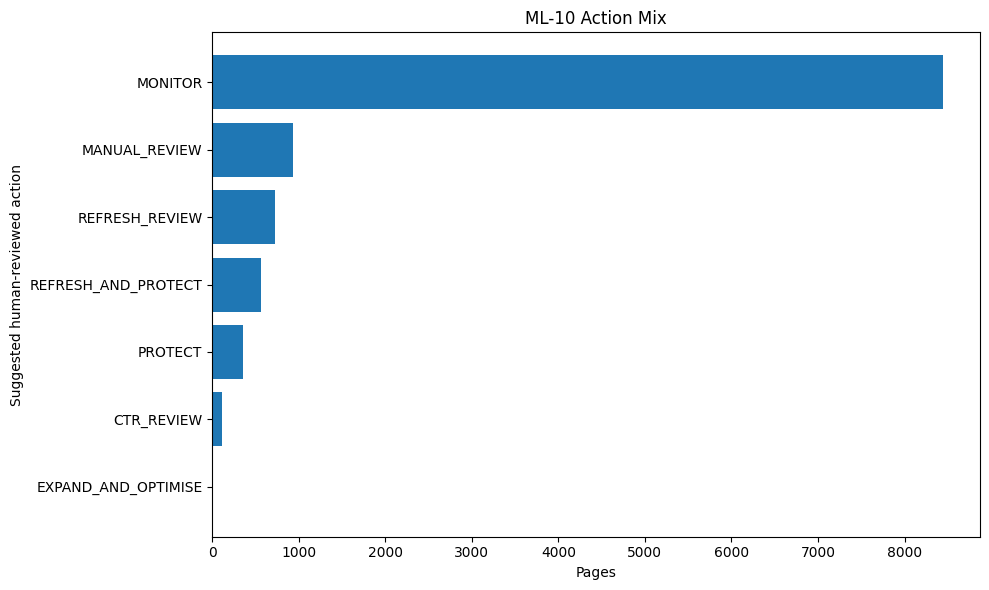

Saved: work/figures/ml10_action_mix.png


In [18]:
action_counts = (
    queue_export[
        "action_label"
    ]
    .value_counts()
    .sort_values(
        ascending=True
    )
)

plt.figure(
    figsize=(
        10,
        6,
    )
)

plt.barh(
    action_counts.index,
    action_counts.values,
)

plt.xlabel(
    "Pages"
)

plt.ylabel(
    "Suggested human-reviewed action"
)

plt.title(
    "ML-10 Action Mix"
)

plt.tight_layout()

action_mix_path = (
    FIGURE_DIR
    / "ml10_action_mix.png"
)

plt.savefig(
    action_mix_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    action_mix_path,
)

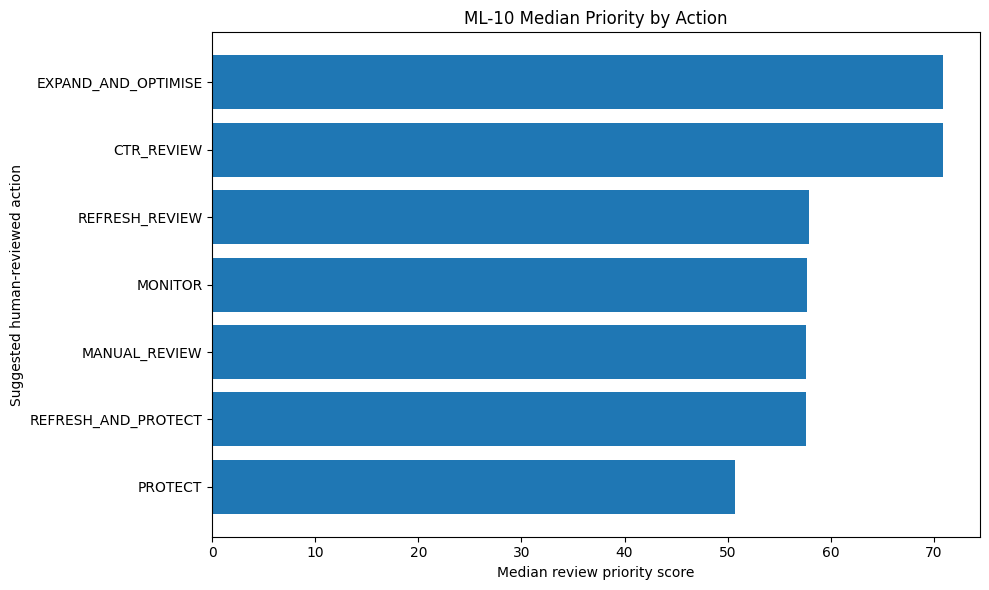

Saved: work/figures/ml10_priority_by_action.png


In [19]:
priority_by_action = (
    queue_export
    .groupby(
        "action_label",
        observed=True,
    )[
        "review_priority_score"
    ]
    .median()
    .sort_values(
        ascending=True
    )
)

plt.figure(
    figsize=(
        10,
        6,
    )
)

plt.barh(
    priority_by_action.index,
    priority_by_action.values,
)

plt.xlabel(
    "Median review priority score"
)

plt.ylabel(
    "Suggested human-reviewed action"
)

plt.title(
    "ML-10 Median Priority by Action"
)

plt.tight_layout()

priority_figure_path = (
    FIGURE_DIR
    / "ml10_priority_by_action.png"
)

plt.savefig(
    priority_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    priority_figure_path,
)

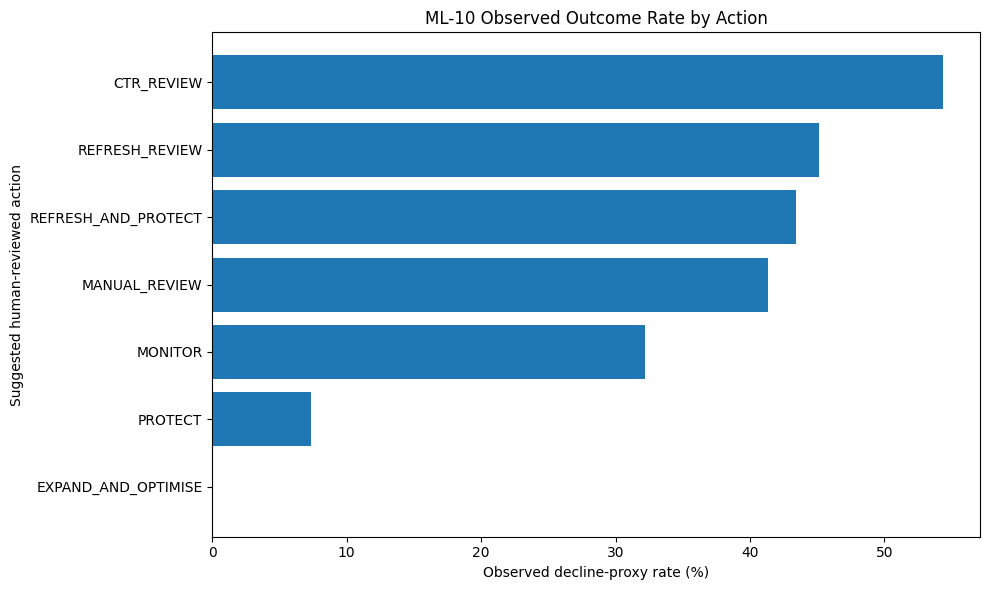

Saved: work/figures/ml10_observed_decline_by_action.png
This figure is observational and does not show the causal effect of taking an action.


In [20]:
decline_by_action = (
    actionable_queue
    .groupby(
        "action_label",
        observed=True,
    )
    .agg(
        observed_decline_rate=(
            target_column,
            "mean",
        ),
        n=(
            target_column,
            "size",
        ),
    )
)

decline_by_action[
    "observed_decline_rate"
] = (
    100
    *
    decline_by_action[
        "observed_decline_rate"
    ]
)

decline_by_action = (
    decline_by_action
    .sort_values(
        "observed_decline_rate",
        ascending=True,
    )
)

plt.figure(
    figsize=(
        10,
        6,
    )
)

plt.barh(
    decline_by_action.index,
    decline_by_action[
        "observed_decline_rate"
    ],
)

plt.xlabel(
    "Observed decline-proxy rate (%)"
)

plt.ylabel(
    "Suggested human-reviewed action"
)

plt.title(
    "ML-10 Observed Outcome Rate by Action"
)

plt.tight_layout()

decline_figure_path = (
    FIGURE_DIR
    / "ml10_observed_decline_by_action.png"
)

plt.savefig(
    decline_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    decline_figure_path,
)

print(
    "This figure is observational and does not "
    "show the causal effect of taking an action."
)

## Self-check

Before submission, this notebook confirms that:

- every section contains markdown reasoning and supporting code;
- the queue has ranked actions, reason codes, archetypes, confidence notes, and cost tiers;
- intended use and limits are explicit;
- refresh is framed as a review recommendation rather than a causal promise;
- human review is required;
- prohibited automations are explicit;
- monitoring and retrain triggers are practical;
- cost/value thinking does not invent financial ROI;
- the queue, JSON receipts, fitted pipeline, and paper figures are exported;
- no client names, raw URLs, or private queries are displayed;
- claims use observed, measured, directional, and decision-support language.

In [21]:
required_queue_columns = {
    "rank",
    "client_hash_id",
    "content_hash_id",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "confidence_note",
    "review_cost_tier",
    "estimated_review_minutes",
    "human_review_required",
}

required_export_files = [
    queue_path,
    action_validation_path,
    capacity_path,
    metrics_path,
    playbook_path,
    monitoring_path,
    human_review_path,
    model_path,
    action_mix_path,
    priority_figure_path,
    decline_figure_path,
]


# ============================================================
# LEAKAGE CHECK FOR ACTION MAPPING
# ============================================================

forbidden_action_inputs = {
    target_column,
    "outcome_impressions",
    "outcome_daily_impressions",
    "client_hash_id",
    "content_hash_id",
}

assert ACTION_INPUT_COLUMNS.isdisjoint(
    forbidden_action_inputs
)


# ============================================================
# SORT CHECK
# ============================================================

priority_values = queue_export[
    "review_priority_score"
].to_numpy(
    dtype=float
)

priority_is_descending = bool(
    np.all(
        np.diff(
            priority_values
        ) <= 0
    )
)


# ============================================================
# EXECUTABLE SELF-CHECK
# ============================================================

self_checks = {
    "Ranked queue is non-empty": (
        len(
            queue_export
        ) > 0
    ),

    "Queue has required columns": (
        required_queue_columns
        .issubset(
            queue_export.columns
        )
    ),

    "Ranks are sequential": (
        queue_export[
            "rank"
        ].tolist()
        ==
        list(
            range(
                1,
                len(
                    queue_export
                ) + 1,
            )
        )
    ),

    "Queue is sorted by priority": (
        priority_is_descending
    ),

    "Priority scores are finite": (
        np.isfinite(
            queue_export[
                "review_priority_score"
            ]
        ).all()
    ),

    "Model scores are finite": (
        np.isfinite(
            queue_export[
                "model_score"
            ]
        ).all()
    ),

    "Reason codes are populated": (
        queue_export[
            "reason_code"
        ]
        .astype(str)
        .str.len()
        .gt(0)
        .all()
    ),

    "Action labels are populated": (
        queue_export[
            "action_label"
        ]
        .astype(str)
        .str.len()
        .gt(0)
        .all()
    ),

    "All exported actions require review": (
        queue_export[
            "human_review_required"
        ].eq(True).all()
    ),

    "Human review rules exist": (
        len(
            human_review_checklist
        ) >= 8
    ),

    "No-go list exists": (
        len(
            no_go_list
        ) >= 6
    ),

    "Monitoring triggers exist": (
        len(
            monitoring_triggers
        ) >= 8
    ),

    "Grouped client overlap is zero": (
        client_overlap == 0
    ),

    "Target excluded from model features": (
        target_column
        not in feature_columns
    ),

    "Identifiers excluded from model features": (
        group_column
        not in feature_columns

        and

        "content_hash_id"
        not in feature_columns
    ),

    "Outcome fields excluded from model features": (
        "outcome_impressions"
        not in feature_columns

        and

        "outcome_daily_impressions"
        not in feature_columns
    ),

    "Outcome excluded from action mapping": (
        ACTION_INPUT_COLUMNS
        .isdisjoint(
            forbidden_action_inputs
        )
    ),

    "No monetary ROI claim": (
        playbook_metrics[
            "monetary_roi_claim"
        ]
        is False
    ),

    "No causal refresh claim": (
        playbook_metrics[
            "causal_refresh_claim"
        ]
        is False
    ),

    "No automatic action": (
        playbook_metrics[
            "automatic_action"
        ]
        is False
    ),

    "No placeholder values used": (
        playbook_metrics[
            "placeholder_values_used"
        ]
        is False
    ),

    "Actual fitted pipeline saved": (
        hasattr(
            playbook_model,
            "predict_proba",
        )

        and

        model_path.exists()
    ),

    "All required exports exist": all(
        path.exists()
        for path in required_export_files
    ),
}

self_check_df = pd.DataFrame(
    {
        "check": list(
            self_checks.keys()
        ),
        "passed": list(
            self_checks.values()
        ),
    }
)

display(
    self_check_df
)

failed_checks = [
    check_name
    for check_name, passed
    in self_checks.items()
    if not passed
]

if failed_checks:

    raise AssertionError(
        "Self-check failed: "
        +
        ", ".join(
            failed_checks
        )
    )

print(
    "Saved queue:",
    queue_path,
)

print(
    "Saved metrics JSON:",
    metrics_path,
)

print(
    "Saved figures:",
    FIGURE_DIR,
)

print(
    "All ML-10 self-checks passed."
)

,check,passed
0,Ranked queue is non-empty,True
1,Queue has required columns,True
2,Ranks are sequential,True
3,Queue is sorted by priority,True
4,Priority scores are finite,True
5,Model scores are finite,True
6,Reason codes are populated,True
7,Action labels are populated,True
8,All exported actions require review,True
9,Human review rules exist,True


Saved queue: work/outputs/content_action_playbook_queue.csv
Saved metrics JSON: work/outputs/content_action_playbook_metrics.json
Saved figures: work/figures
All ML-10 self-checks passed.
